# Dataset Amazon-Reviews-2023-Books-Review

In [1]:
from datasets import load_dataset

dataset = load_dataset(
    "cogsci13/Amazon-Reviews-2023-Books-Review",
    split="full",
    streaming=True
)

dataset_big_sample = dataset.shuffle(buffer_size=1_500_000, seed=42)
dataset = dataset_big_sample.take(15000)


Resolving data files:   0%|          | 0/33 [00:00<?, ?it/s]

Pobieram 1.5 miliona próbek z 29.5 miliona dostępnych. Taka ilość przerasta potrzeby modelowania oraz moce przerobowe mojego komputera. Z 1.5 miliona wybieram 15000. Powodem początkowego wybrania 1.5 miliona jest chęć zapewnienia większej przypadkowości doboru próbki.

In [2]:
import pandas as pd

df_reviews = pd.DataFrame(dataset)
df_sample = df_reviews.sample(n=100)

df_sample.to_csv("../data/sample/sample_amazon_reviews_2023.tsv", index=False, sep='\t')
df_reviews.to_csv("../data/raw/amazon_reviews_2023.tsv", index=False, sep='\t')

Zapisuje zarówno 15k które użyje do projektu jak i 100 przykladów, które trafi do repo jako sample.

In [3]:
df_reviews.info()
df_reviews.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             15000 non-null  float64
 1   title              15000 non-null  object 
 2   text               15000 non-null  object 
 3   images             15000 non-null  object 
 4   asin               15000 non-null  object 
 5   parent_asin        15000 non-null  object 
 6   user_id            15000 non-null  object 
 7   timestamp          15000 non-null  int64  
 8   helpful_vote       15000 non-null  int64  
 9   verified_purchase  15000 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 1.0+ MB


,rating,timestamp,helpful_vote
count,15000.000000,1.500000e+04,15000.000000
mean,4.417867,1.450553e+12,1.962067
std,1.053120,1.410501e+11,12.085262
min,1.000000,8.582857e+11,0.000000
25%,4.000000,1.388441e+12,0.000000
50%,5.000000,1.462554e+12,0.000000
75%,5.000000,1.547492e+12,1.000000
max,5.000000,1.683045e+12,794.000000


Widzimy, że nie mamy pustych wartości, mamy 10 kolumn. Najbardziej interesujące są dane o ratingu, ponad połowa z nich to 5, a większość jest pozytywna (4, 5).

In [4]:
df_reviews.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

isnull().sum() jest zbędne po wcześniejszych komendach, ale postanowiłem je zostawić.

In [5]:
df_reviews.duplicated(subset=["text"]).sum()

458

Mamy 458 duplikatów

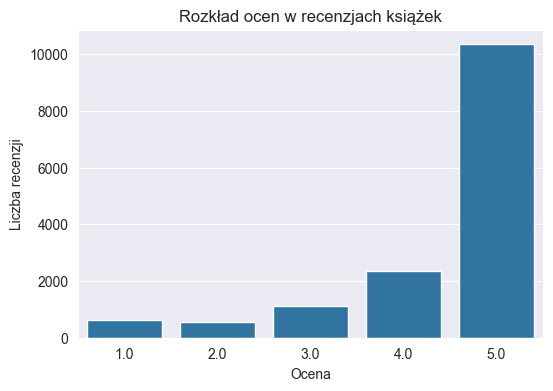

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=df_reviews)
plt.title("Rozkład ocen w recenzjach książek")
plt.xlabel("Ocena")
plt.ylabel("Liczba recenzji")
plt.show()

Wykres przedstawia rozkład ocen w recenzjach książkach. Dominacja 5.0 jest ogromna. Może to powodować problemy przy treningu.

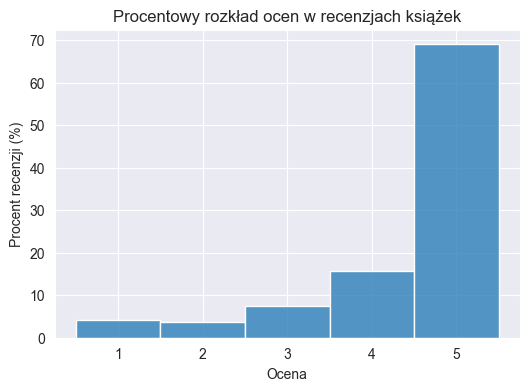

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(x="rating", data=df_reviews, stat="percent", discrete=True)

plt.title("Procentowy rozkład ocen w recenzjach książek")
plt.xlabel("Ocena")
plt.ylabel("Procent recenzji (%)")
plt.show()

Dodatkowy wykres procentowy, widzimy, że niewiele ponad 30% recenzji jest poniżej 5.0, myślałem o zmianie random sample, aby polepszyć ten rozkład, ale z kary datasetu na HF wynika, że w całym datasecie 1 występuje tylko 3.7%, 2 - 3.7%. 3 - 7.8%, 4 - 16,7% a 5 - 68.1%. Oznacza to, że mamy lepszą sytuację niż cały dataset, przy czym zachowane propocje są podobne do oryginalnych.

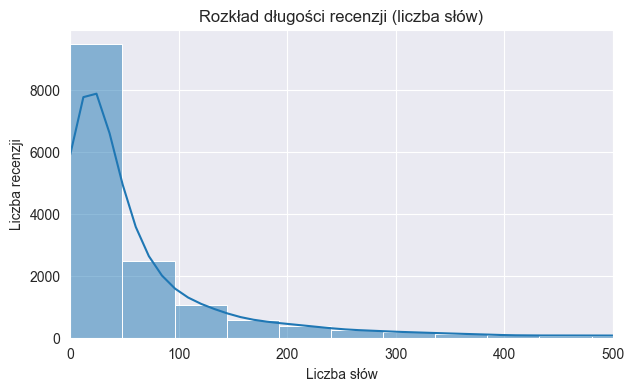

In [8]:
df_reviews["review_length_chars"] = df_reviews["text"].str.len()
df_reviews["review_length_words"] = df_reviews["text"].str.split().apply(len)

plt.figure(figsize=(7,4))
sns.histplot(df_reviews["review_length_words"], bins=50, kde=True)
plt.xlim(0, 500)
plt.title("Rozkład długości recenzji (liczba słów)")
plt.xlabel("Liczba słów")
plt.ylabel("Liczba recenzji")
plt.show()